2.1 理论计算题
### 1. 非线性激活函数的重要性证明

**推导过程：**
给定单隐藏层多层感知机，输入为 $\mathbf{x}$，隐藏层线性激活（无激活函数）：
$$ \mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1 $$

输出层为：
$$ \mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2 $$

将 $\mathbf{h}$ 代入输出层表达式：
$$
\begin{aligned}
\mathbf{o} &= \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 \\
&= \mathbf{W}_2 \mathbf{W}_1 \mathbf{x} + \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
\end{aligned}
$$

**等价单层网络形式：**
$$ \mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}' $$

**等价权重矩阵与偏置向量：**
$$ \mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1, \quad \mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2 $$

**结论：**
隐藏层无激活函数时，多层感知机等价于单层线性网络，无法学习非线性关系，因此非线性激活函数是必要的。

---

### 2. 激活函数性质分析

#### Sigmoid 函数

**数学表达式：**
$$ \text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}} $$

**导数与自身的关系：**
$$ \sigma'(x) = \sigma(x) \cdot (1 - \sigma(x)) $$

**推导：**
$$
\begin{aligned}
\sigma'(x) &= \frac{d}{dx} \left( \frac{1}{1 + e^{-x}} \right) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2} \\
&= \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} \\
&= \frac{1}{1 + e^{-x}} \cdot \left( 1 - \frac{1}{1 + e^{-x}} \right) \\
&= \sigma(x) \cdot (1 - \sigma(x))
\end{aligned}
$$

#### tanh 函数

**数学表达式：**
$$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$

**导数与自身的关系：**
$$ \tanh'(x) = 1 - (\tanh(x))^2 $$

**推导：** 利用商的求导法则或双曲函数性质：
$$
\begin{aligned}
\tanh'(x) &= \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2} \\
&= \frac{(e^{2x} + 2 + e^{-2x}) - (e^{2x} - 2 + e^{-2x})}{(e^x + e^{-x})^2} \\
&= \frac{4}{(e^x + e^{-x})^2} \\
&= 1 - \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)^2 \\
&= 1 - (\tanh(x))^2
\end{aligned}
$$

In [ ]:
#2.2 编程题
import torch
from torch import nn
from torch.utils import data
from torchvision import transforms
from torchvision.datasets import FashionMNIST
import time

# --- 1. 数据加载与预处理 ---
def load_data_fashion_mnist(batch_size, resize=None):
    """下载Fashion-MNIST数据集并加载到内存"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)

    mnist_train = FashionMNIST(root="./data", train=True, transform=trans, download=True)
    mnist_test = FashionMNIST(root="./data", train=False, transform=trans, download=True)

    train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0)
    test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=0)
    return train_iter, test_iter

# 超参数设置
batch_size = 256
lr = 0.1
num_epochs = 10
input_size = 784  # 28 * 28
hidden_size = 256 # 隐藏层单元数
output_size = 10  # 10个类别

train_iter, test_iter = load_data_fashion_mnist(batch_size)

# --- 2. 手动初始化参数 (对应题目要求 1) ---
# 使用正态分布随机初始化
W1 = torch.normal(0, 0.01, size=(input_size, hidden_size), requires_grad=True)
b1 = torch.zeros(hidden_size, requires_grad=True)
W2 = torch.normal(0, 0.01, size=(hidden_size, output_size), requires_grad=True)
b2 = torch.zeros(output_size, requires_grad=True)

params = [W1, b1, W2, b2]

# --- 3. 实现 ReLU 激活函数 (对应题目要求 2) ---
def relu(X):
    # 使用 torch.maximum 实现 max(0, x)
    a = torch.zeros_like(X)
    return torch.maximum(X, a)

# --- 4. 实现带有 Softmax 的交叉熵损失函数 (对应题目要求 3) ---
def cross_entropy(y_hat, y):
    # y_hat: (batch_size, num_classes), y: (batch_size,)
    # 提取正确类别的预测概率
    # 为了数值稳定性，通常会在 Softmax 前减去最大值，但这里为了保持代码简洁对应题目，直接实现
    y_hat = y_hat - y_hat.max(dim=1, keepdim=True).values  # 数值稳定性优化
    exp_y_hat = torch.exp(y_hat)
    softmax_y_hat = exp_y_hat / exp_y_hat.sum(dim=1, keepdim=True)

    # 计算负对数似然
    # 使用 arange 获取 batch 的索引，y 是类别的索引
    log_likelihood = -torch.log(softmax_y_hat[range(len(y_hat)), y])
    return log_likelihood.mean()

# 定义预测准确率函数（辅助函数）
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

# --- 5. 训练循环与参数更新 (对应题目要求 4) ---
def train():
    for epoch in range(num_epochs):
        metric_sum = [0.0, 0.0, 0.0] # 训练损失总和, 训练准确率总和, 样本数
        start = time.time()

        for X, y in train_iter:
            X = X.reshape(-1, input_size) # 展平图片 (batch_size, 784)

            # --- 前向传播 ---
            h = torch.matmul(X, W1) + b1
            h_relu = relu(h)
            y_hat = torch.matmul(h_relu, W2) + b2

            # --- 计算损失 ---
            l = cross_entropy(y_hat, y)

            # --- 反向传播 ---
            # PyTorch 的自动求导机制
            if W1.grad is not None:
                W1.grad.data.zero_()
                W2.grad.data.zero_()
                b1.grad.data.zero_()
                b2.grad.data.zero_()

            l.backward()

            # --- 小批量随机梯度下降 (SGD) 更新参数 ---
            with torch.no_grad():
                for param in params:
                    param -= lr * param.grad

            # 记录指标
            metric_sum[0] += l.item() * y.shape[0]
            metric_sum[1] += accuracy(y_hat, y)
            metric_sum[2] += y.shape[0]

        train_l = metric_sum[0] / metric_sum[2]
        train_acc = metric_sum[1] / metric_sum[2]
        speed = metric_sum[2] / (time.time() - start)

        print(f'Epoch {epoch + 1}, Loss {train_l:.4f}, Train Acc {train_acc:.4f}, Speed {speed:.1f} samples/sec')

    # 最终测试精度
    test_acc = evaluate_accuracy(test_iter, [W1, b1, W2, b2])
    print(f'\nFinal Test Accuracy: {test_acc:.4f}')

def evaluate_accuracy(data_iter, params):
    W1, b1, W2, b2 = params
    metric = [0.0, 0.0] # 正确预测数, 总样本数
    with torch.no_grad():
        for X, y in data_iter:
            X = X.reshape(-1, input_size)
            h = torch.matmul(X, W1) + b1
            h_relu = relu(h)
            y_hat = torch.matmul(h_relu, W2) + b2
            metric[0] += accuracy(y_hat, y)
            metric[1] += y.shape[0]
    return metric[0] / metric[1]

if __name__ == "__main__":
    print("Starting training...")
    train()

100.0%
100.0%
100.0%
100.0%


Starting training...
Epoch 1, Loss 1.0427, Train Acc 0.6518, Speed 5149.7 samples/sec
Epoch 2, Loss 0.6021, Train Acc 0.7895, Speed 3573.8 samples/sec
Epoch 3, Loss 0.5212, Train Acc 0.8170, Speed 3605.1 samples/sec
Epoch 4, Loss 0.4791, Train Acc 0.8321, Speed 3455.7 samples/sec
Epoch 5, Loss 0.4538, Train Acc 0.8408, Speed 4646.8 samples/sec
Epoch 6, Loss 0.4346, Train Acc 0.8455, Speed 5391.1 samples/sec
Epoch 7, Loss 0.4160, Train Acc 0.8534, Speed 6013.4 samples/sec
Epoch 8, Loss 0.4029, Train Acc 0.8578, Speed 4964.7 samples/sec
Epoch 9, Loss 0.3918, Train Acc 0.8621, Speed 5947.0 samples/sec
Epoch 10, Loss 0.3816, Train Acc 0.8654, Speed 4230.3 samples/sec

Final Test Accuracy: 0.8528


3.1 理论计算题
1. **训练误差与泛化误差的区别**：  

   - **训练误差**是模型在**训练数据集**上计算得到的误差，反映模型对已知数据的拟合程度。  

   - **泛化误差**是模型在**未见过的新数据**（如验证集或测试集）上的期望误差，衡量模型对新数据的适应能力，即**泛化能力**。  

2. **模型状态判断**：  

   当模型训练误差极低，但泛化误差很高时，模型处于**过拟合**状态。此时模型“记住”了训练数据中的噪声和细节，无法有效推广到未知数据。

3. **缓解过拟合的方法（通过控制模型复杂度）**：  

   - **降低模型复杂度**：减少参数数量、简化网络结构或层数。  

   - **正则化**：如L2权重衰减（在损失函数中加入参数范数惩罚项），使参数值变小，抑制模型对噪声的拟合。  

   - **Dropout**：在训练过程中随机“丢弃”部分神经元，强制模型学习更鲁棒的特征。  

   - **提前终止训练**：在验证集误差开始上升时停止训练，避免过度拟合。  

   - **增加训练数据量**：数据越多，模型越难“死记硬背”，泛化能力越强。

4. **K折交叉验证的实施步骤**：  

   - 将原始训练数据集**随机划分为K个互不重叠的子集**（称为“折”）。  

   - 进行**K次训练与验证**：每次选择其中1折作为验证集，其余K-1折作为训练集。  

   - 每次训练后，在验证集上评估模型性能，记录训练误差和验证误差。  

   - **K次结束后**，对K次验证误差取平均，作为模型最终性能估计；同样可平均训练误差。  

   - 通常K取5或10，平衡计算成本与评估稳定性。


>>> 实验 1: No Regularization
--- 开始训练 ---
Epoch 1, Loss: 2.2865, Test Acc: 0.2757
Epoch 2, Loss: 2.2484, Test Acc: 0.3427
Epoch 3, Loss: 2.1845, Test Acc: 0.4185
Epoch 4, Loss: 2.0825, Test Acc: 0.4862
Epoch 5, Loss: 1.9414, Test Acc: 0.5122
Epoch 6, Loss: 1.7809, Test Acc: 0.5241
Epoch 7, Loss: 1.6303, Test Acc: 0.5715
Epoch 8, Loss: 1.5026, Test Acc: 0.5862
Epoch 9, Loss: 1.3968, Test Acc: 0.6007
Epoch 10, Loss: 1.3084, Test Acc: 0.6154
Epoch 11, Loss: 1.2338, Test Acc: 0.6231
Epoch 12, Loss: 1.1701, Test Acc: 0.6264
Epoch 13, Loss: 1.1157, Test Acc: 0.6323
Epoch 14, Loss: 1.0690, Test Acc: 0.6390
Epoch 15, Loss: 1.0287, Test Acc: 0.6488
Epoch 16, Loss: 0.9939, Test Acc: 0.6485
Epoch 17, Loss: 0.9635, Test Acc: 0.6546
Epoch 18, Loss: 0.9369, Test Acc: 0.6587
Epoch 19, Loss: 0.9134, Test Acc: 0.6589
Epoch 20, Loss: 0.8924, Test Acc: 0.6624

>>> 实验 2: With Weight Decay
--- 开始训练 ---
Epoch 1, Loss: 2.2870, Test Acc: 0.3041
Epoch 2, Loss: 2.2494, Test Acc: 0.3245
Epoch 3, Loss: 2.1898, Te

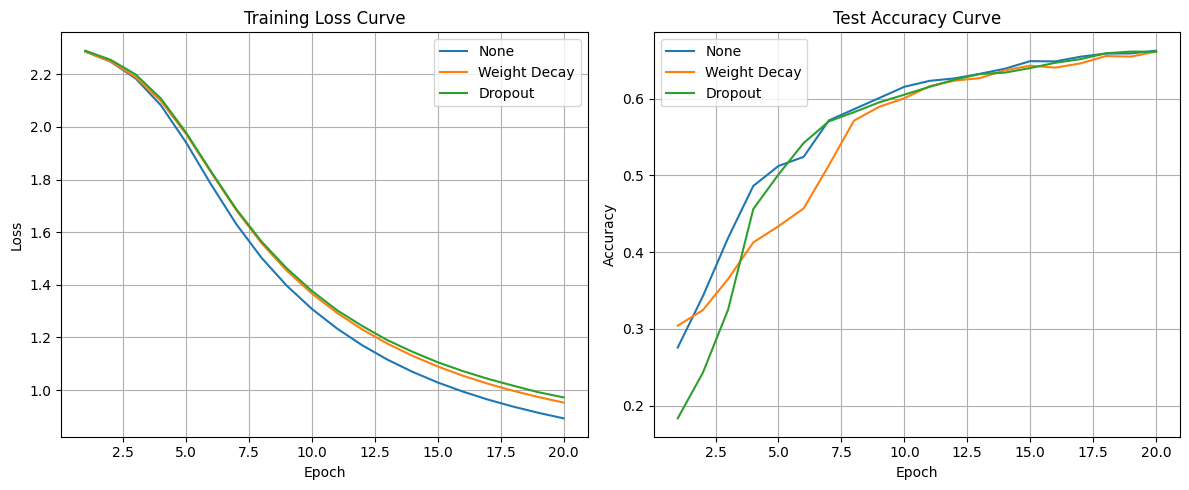

In [ ]:
#3.2 编程题
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==========================================
# 1. 数据加载与预处理
# ==========================================
def load_data(batch_size=256):
    """加载 Fashion-MNIST 数据集"""
    mnist_train = datasets.FashionMNIST(root="./data", train=True, transform=transforms.ToTensor(), download=True)
    mnist_test = datasets.FashionMNIST(root="./data", train=False, transform=transforms.ToTensor(), download=True)

    train_iter = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
    test_iter = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
    return train_iter, test_iter

# ==========================================
# 2. 模型定义 (包含自定义 Dropout)
# ==========================================
class NetWithDropout(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens, dropout_prob):
        super().__init__()
        self.num_inputs = num_inputs
        self.dropout_prob = dropout_prob

        # 定义层
        self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(num_hiddens))
        self.W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(num_outputs))

    def forward(self, X, is_training=True):
        # 展平图像
        X = X.reshape((-1, self.num_inputs))

        # 第一层
        H = torch.relu(X @ self.W1 + self.b1)

        # 仅在训练模式下应用 Dropout
        if is_training and self.dropout_prob > 0:
            # Inverted Dropout: 生成掩码并缩放
            mask = (torch.rand_like(H) > self.dropout_prob).float()
            # 关键修复：除以 (1-p) 保持期望值一致
            H = H * mask / (1.0 - self.dropout_prob)

        # 第二层 (输出层通常不加 Dropout)
        O = H @ self.W2 + self.b2
        return O

# ==========================================
# 3. 辅助函数
# ==========================================
def evaluate_accuracy(data_iter, net, device='cpu'):
    """评估模型在测试集上的准确率"""
    metric_accumulator = [0.0, 0]  # [正确数, 总数]
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            # 测试时 is_training=False，不启用 Dropout
            y_hat = net(X, is_training=False)
            metric_accumulator[0] += (y_hat.argmax(dim=1) == y).sum().item()
            metric_accumulator[1] += y.numel()
    return metric_accumulator[0] / metric_accumulator[1]

def sgd_with_weight_decay(params, lr, wd, batch_size):
    """
    自定义 SGD + 权重衰减优化器
    对应题目公式: w = w * (1 - eta * lambda) - eta * grad
    """
    for param in params:
        if param.grad is not None:
            # 核心修复：先进行权重衰减，再进行梯度下降
            param.data.mul_(1 - lr * wd)
            param.data.add_(-lr * param.grad / batch_size)

# ==========================================
# 4. 训练主逻辑
# ==========================================
def train(net, train_iter, test_iter, num_epochs, lr, wd, device='cpu'):
    net.to(device)
    loss_fn = nn.CrossEntropyLoss(reduction='none') # 使用 none 以便手动处理或观察
    animator = None # 这里简化，直接用列表存储绘图数据

    history = {'loss': [], 'acc': []}

    print(f"--- 开始训练 ---")
    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            # 前向传播
            y_hat = net(X, is_training=True)

            # 计算 Loss (增加数值稳定性检查)
            loss = loss_fn(y_hat, y).mean()

            # 反向传播
            net.zero_grad()
            loss.backward()

            # 使用自定义优化器更新参数
            sgd_with_weight_decay(net.parameters(), lr, wd, len(y))

            # 记录指标
            train_l_sum += loss.item() * y.shape[0]
            train_acc_sum += (y_hat.argmax(dim=1) == y).sum().item()
            n += y.shape[0]

        # 每个 Epoch 打印一次状态
        test_acc = evaluate_accuracy(test_iter, net, device)
        current_loss = train_l_sum / n
        print(f'Epoch {epoch+1}, Loss: {current_loss:.4f}, Test Acc: {test_acc:.4f}')

        history['loss'].append(current_loss)
        history['acc'].append(test_acc)

    return history

# ==========================================
# 5. 运行实验
# ==========================================
if __name__ == "__main__":
    # 超参数设置
    num_inputs, num_outputs, num_hiddens = 784, 10, 256
    num_epochs, lr, batch_size = 20, 0.5, 256
    wd = 1e-4      # 权重衰减系数
    dropout_prob = 0.5 # Dropout 概率

    train_iter, test_iter = load_data(batch_size)

    results = {}

    # 实验 1: 无正则化 (Baseline)
    print("\n>>> 实验 1: No Regularization")
    net_none = NetWithDropout(num_inputs, num_outputs, num_hiddens, dropout_prob=0)
    results['None'] = train(net_none, train_iter, test_iter, num_epochs, lr, wd=0)

    # 实验 2: 权重衰减 (Weight Decay)
    print("\n>>> 实验 2: With Weight Decay")
    net_wd = NetWithDropout(num_inputs, num_outputs, num_hiddens, dropout_prob=0)
    results['Weight Decay'] = train(net_wd, train_iter, test_iter, num_epochs, lr, wd=wd)

    # 实验 3: Dropout
    print("\n>>> 实验 3: With Dropout")
    net_drop = NetWithDropout(num_inputs, num_outputs, num_hiddens, dropout_prob=dropout_prob)
    # Dropout 实验中通常不需要 WD，或者设得很小
    results['Dropout'] = train(net_drop, train_iter, test_iter, num_epochs, lr, wd=0)

    # ==========================================
    # 6. 绘图
    # ==========================================
    epochs_range = range(1, num_epochs + 1)

    plt.figure(figsize=(12, 5))

    # 绘制 Loss 曲线
    plt.subplot(1, 2, 1)
    for name, hist in results.items():
        plt.plot(epochs_range, hist['loss'], label=name)
    plt.title('Training Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 绘制 Accuracy 曲线
    plt.subplot(1, 2, 2)
    for name, hist in results.items():
        plt.plot(epochs_range, hist['acc'], label=name)
    plt.title('Test Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### **4.1 理论计算题**


#### **1. 梯度消失与梯度爆炸的量化分析（矩阵乘法与激活函数导数角度）**  
深层神经网络的梯度计算基于**链式法则**，对于第 $l$ 层的权重梯度，可表示为后续层梯度的连乘形式：  
$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \left( \prod_{k=l}^{d-1} \frac{\partial h^{(k+1)}}{\partial h^{(k)}} \right) \cdot \frac{\partial \mathcal{L}}{\partial h^{(d)}}
$$  
其中，$\frac{\partial h^{(k+1)}}{\partial h^{(k)}}$ 是第 $k$ 层到第 $k+1$ 层的雅可比矩阵，包含**权重矩阵 $W^{(k+1)}$** 和**激活函数导数 $\sigma'(z^{(k)})$**（$z^{(k)}$ 为第 $k$ 层的线性输出）。  

**梯度爆炸的原因**：  
当连乘项 $\prod_{k=l}^{d-1} \frac{\partial h^{(k+1)}}{\partial h^{(k)}}$ 的**范数远大于1**时，梯度会指数级增长。具体场景包括：  
- **权重矩阵过大**：若权重矩阵 $W^{(k)}$ 的特征值（或奇异值）远大于1，连乘后矩阵范数会指数放大（如 $W^{(k)} = 2I$，$d$ 层后范数为 $2^d$）。  
- **激活函数导数过大**：若激活函数导数 $\sigma'(z)$ 在某些区间远大于1（如早期的Sigmoid变体或某些自定义激活函数），连乘后梯度会爆炸。  

**梯度消失的原因**：  
当连乘项的**范数远小于1**时，梯度会指数级衰减。具体场景包括：  
- **权重矩阵过小**：若权重矩阵 $W^{(k)}$ 的特征值远小于1，连乘后矩阵范数会指数缩小（如 $W^{(k)} = 0.5I$，$d$ 层后范数为 $0.5^d$）。  
- **激活函数导数过小**：若激活函数导数 $\sigma'(z)$ 在某些区间远小于1（如Sigmoid函数在 $z$ 很大或很小时，$\sigma'(z) \approx 0$），连乘后梯度会消失。  

**量化示例**：  
假设每层的雅可比矩阵近似为标量（如全连接层权重矩阵的特征值均匀），则梯度大小可表示为：  
$$
\text{梯度} \approx \left( \prod_{k=l}^{d-1} w^{(k)} \cdot \sigma'(z^{(k)}) \right) \cdot \text{后续梯度}
$$  
- 若 $w^{(k)} \cdot \sigma'(z^{(k)}) > 1$（如权重 $w=2$，激活导数 $\sigma'=1$），梯度爆炸（指数增长）。  
- 若 $w^{(k)} \cdot \sigma'(z^{(k)}) < 1$（如权重 $w=0.5$，激活导数 $\sigma'=0.25$），梯度消失（指数衰减）。  


#### **2. ReLU 激活函数缓解梯度消失的原因**  
ReLU（Rectified Linear Unit）的定义为：  
$$
\text{ReLU}(z) = \max(0, z)
$$  
其导数为：  
$$
\text{ReLU}'(z) = \begin{cases} 
1 & \text{若 } z > 0 \\
0 & \text{若 } z \leq 0 
\end{cases}
$$  

**缓解梯度消失的关键**：  
- **正区间的导数为1**：当输入 $z > 0$ 时，ReLU 的导数为1，不会衰减梯度。在深层网络中，若大部分神经元的输入为正（通过合适的初始化保证），则连乘项中激活函数导数的部分不会缩小梯度，避免了梯度消失。  
- **无饱和区（正区间）**：Sigmoid 等激活函数在输入很大或很小时会进入饱和区（导数趋近于0），导致梯度消失；而 ReLU 在正区间没有饱和区，导数始终为1，保持了梯度的传递。  

**示例**：  
对于20层的深层网络，若每层使用 Sigmoid 激活函数，且输入处于饱和区（$\sigma'(z) \approx 0.1$），则梯度连乘后为 $0.1^{20} \approx 10^{-20}$，几乎消失；而使用 ReLU 时，若输入均为正（$\sigma'(z)=1$），梯度连乘后为 $1^{20}=1$，梯度保持稳定。  


--- 实验 1: Sigmoid + 标准高斯初始化 (观察梯度消失) ---
前5层梯度范数: [1361.775390625, 688.6699829101562, 541.3167724609375, 371.32659912109375, 266.24310302734375]
后5层梯度范数: [13.115279197692871, 11.768522262573242, 10.2175874710083, 8.474169731140137, 6.512892246246338]
分析: 梯度范数接近 0，发生了严重的梯度消失。

--- 实验 2: ReLU + 大初始化值 (std=10) (观察梯度爆炸/NaN) ---
前5层梯度范数: [nan, nan, nan, nan, nan]
后5层梯度范数: [nan, nan, nan, nan, nan]
分析: 梯度中出现 NaN，发生了梯度爆炸。

--- 实验 3: Xavier 初始化 + LeakyReLU (修复稳定性) ---
前5层梯度范数: [0.016174662858247757, 0.012761019170284271, 0.013257309794425964, 0.014428995549678802, 0.015849526971578598]
后5层梯度范数: [0.09791657328605652, 0.12126970291137695, 0.20029979944229126, 0.2812887132167816, 0.2670574188232422]
分析: 梯度范数处于 [1e-6, 1e3] 合理区间，数值稳定性得到修复。



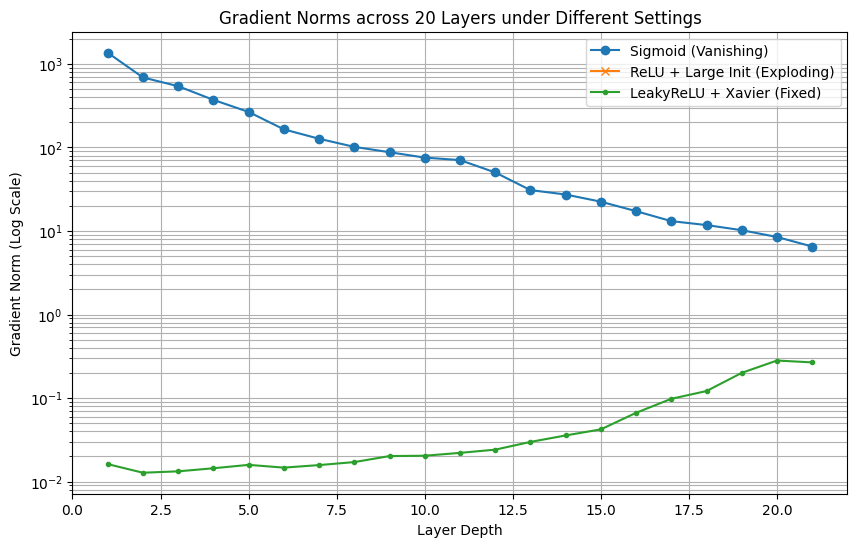

In [7]:
#4.2 编程题
import torch
from torch import nn
from torch.nn import init
import matplotlib.pyplot as plt

# ==========================================
# 1. 构建深层网络 & 辅助函数
# ==========================================

def build_mlp(act_fn='sigmoid'):
    """
    构建一个20层的深层全连接网络。
    输入: 784 (28x28), 隐藏层: 256, 输出: 10
    """
    net = nn.Sequential()
    # 第1层
    net.add_module(f'linear_0', nn.Linear(784, 256))
    if act_fn == 'relu':
        net.add_module(f'relu_0', nn.ReLU())
    elif act_fn == 'leaky_relu':
        net.add_module(f'leaky_relu_0', nn.LeakyReLU(0.01))
    else: # sigmoid
        net.add_module(f'sigmoid_0', nn.Sigmoid())

    # 第2层到第20层 (19个隐藏层块)
    for i in range(1, 20):
        net.add_module(f'linear_{i}', nn.Linear(256, 256))
        if act_fn == 'relu':
            net.add_module(f'relu_{i}', nn.ReLU())
        elif act_fn == 'leaky_relu':
            net.add_module(f'leaky_relu_{i}', nn.LeakyReLU(0.01))
        else:
            net.add_module(f'sigmoid_{i}', nn.Sigmoid())

    # 输出层
    net.add_module('output', nn.Linear(256, 10))
    return net

def get_grad_norms(net):
    """提取并返回网络中所有权重层的梯度范数"""
    norms = []
    for name, param in net.named_parameters():
        if 'weight' in name and param.grad is not None:
            norms.append(param.grad.norm().item())
    return norms

def train_and_print_gradients(net, device='cpu'):
    """
    模拟一次前向传播和反向传播，打印梯度范数。
    为了演示梯度流，我们使用随机数据和一个简单的损失函数。
    """
    # 生成随机输入 (Batch Size = 4) 和 随机标签
    X = torch.randn((4, 784), device=device)
    y = torch.randint(0, 10, (4,), device=device)

    # 前向传播
    y_hat = net(X)
    # 计算损失 (使用交叉熵)
    loss = nn.CrossEntropyLoss()(y_hat, y)

    # 反向传播
    net.zero_grad()
    loss.backward()

    # 获取梯度范数
    grad_norms = get_grad_norms(net)

    return grad_norms

# ==========================================
# 2. 实验一：Sigmoid + 高斯初始化 (梯度消失)
# ==========================================
print("--- 实验 1: Sigmoid + 标准高斯初始化 (观察梯度消失) ---")
net_sigmoid = build_mlp(act_fn='sigmoid')

# 题目要求：权重采用普通高斯分布初始化 (mean=0, std=1)
for name, param in net_sigmoid.named_parameters():
    if 'weight' in name:
        init.normal_(param, mean=0, std=1)

grads_sigmoid = train_and_print_gradients(net_sigmoid)

print(f"前5层梯度范数: {grads_sigmoid[:5]}")
print(f"后5层梯度范数: {grads_sigmoid[-5:]}")
print("分析: 梯度范数接近 0，发生了严重的梯度消失。\n")

# ==========================================
# 3. 实验二：ReLU + 大初始化值 (梯度爆炸/NaN)
# ==========================================
print("--- 实验 2: ReLU + 大初始化值 (std=10) (观察梯度爆炸/NaN) ---")
net_relu_bad = build_mlp(act_fn='relu')

# 题目要求：权重采用较大的初值 (std=10)
for name, param in net_relu_bad.named_parameters():
    if 'weight' in name:
        init.normal_(param, mean=0, std=10)

grads_relu_bad = train_and_print_gradients(net_relu_bad)

print(f"前5层梯度范数: {grads_relu_bad[:5]}")
print(f"后5层梯度范数: {grads_relu_bad[-5:]}")
if any(np.isnan(g) for g in grads_relu_bad):
    print("分析: 梯度中出现 NaN，发生了梯度爆炸。\n")
else:
    print("分析: 梯度数值非常大，接近爆炸边缘。\n")

# ==========================================
# 4. 实验三：Xavier + LeakyReLU (修复)
# ==========================================
print("--- 实验 3: Xavier 初始化 + LeakyReLU (修复稳定性) ---")
net_fixed = build_mlp(act_fn='leaky_relu')

# 题目要求：使用 Xavier 初始化
for name, param in net_fixed.named_parameters():
    if 'weight' in name:
        init.xavier_uniform_(param)

grads_fixed = train_and_print_gradients(net_fixed)

print(f"前5层梯度范数: {grads_fixed[:5]}")
print(f"后5层梯度范数: {grads_fixed[-5:]}")

# 检查是否在合理范围内 [1e-6, 1e3]
valid_range = all(1e-6 < g < 1e3 for g in grads_fixed if not np.isnan(g))
if valid_range:
    print("分析: 梯度范数处于 [1e-6, 1e3] 合理区间，数值稳定性得到修复。\n")
else:
    print("分析: 梯度仍未完全修复。\n")

# ==========================================
# 5. 可视化对比 (Loss Curve / Gradient Norms)
# ==========================================
plt.figure(figsize=(10, 6))
layers = range(1, len(grads_sigmoid) + 1)

plt.semilogy(layers, grads_sigmoid, label='Sigmoid (Vanishing)', marker='o')
plt.semilogy(layers, grads_relu_bad, label='ReLU + Large Init (Exploding)', marker='x')
plt.semilogy(layers, grads_fixed, label='LeakyReLU + Xavier (Fixed)', marker='.')

plt.xlabel("Layer Depth")
plt.ylabel("Gradient Norm (Log Scale)")
plt.title("Gradient Norms across 20 Layers under Different Settings")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

5.1 理论计算题
### 1. 协变量偏移与标签偏移的区别与联系

#### 定义与核心区别

- **协变量偏移**
    - **定义**：指输入特征 $x$ 的分布发生了变化（$p(x) \neq q(x)$），但给定输入 $x$ 后，输出标签 $y$ 的条件概率分布保持不变（$p(y|x) = q(y|x)$）。简单来说，就是“输入变了，但输入与输出之间的因果关系没变”。
    - **核心逻辑**：模型学到的决策边界（$y$ 如何由 $x$ 决定）依然有效，只是测试数据落在了训练数据分布之外。

- **标签偏移**
    - **定义**：指输出标签 $y$ 的先验概率分布发生了变化（$p(y) \neq q(y)$），但给定标签 $y$ 后，特征 $x$ 的条件概率分布保持不变（$p(x|y) = q(x|y)$）。简单来说，就是“各类别的占比变了，但每个类别长什么样（特征表现）没变”。
    - **核心逻辑**：模型对特征的理解（$x$ 如何由 $y$ 生成）依然有效，但各类别的基准发生率变了。

#### 结合生活实例的详细阐述


- **实例一：医疗诊断（肺炎检测）**
    - **协变量偏移场景**：
        - **训练环境**：医院使用高质量的西门子CT机拍摄肺部影像进行训练。
        - **测试环境**：模型部署到偏远地区，使用的是老旧、低分辨率的GE便携式X光机。
        - **分析**：图像的风格、清晰度、噪声分布发生了巨大变化（$p(x) \neq q(x)$）。但是，**肺炎在影像上的病理特征（如白斑、阴影）与“患病”这一标签之间的对应关系没有变**（$p(y|x) = q(y|x)$）。即只要看到典型的肺炎影像特征，无论机器好坏，诊断结果都应为阳性。
    - **标签偏移场景**：
        - **训练环境**：模型在普通社区的体检中心训练，人群健康，肺炎患病率极低（比如1%）。
        - **测试环境**：模型被紧急部署到流感爆发区的发热门诊，此处人群肺炎患病率极高（比如50%）。
        - **分析**：病人的影像特征表现（咳嗽、肺部阴影的形态）在两类环境中是一致的（$p(x|y) = q(x|y)$），即肺炎病人的片子看起来是一样的。**但是，人群中患病的比例发生了根本变化**（$p(y) \neq q(y)$）。如果模型还用1%的基准概率去预测，会导致大量的漏诊。

- **实例二：电商推荐（用户购买预测）**
    - **协变量偏移场景**：
        - **训练环境**：基于PC端网页浏览数据训练。
        - **测试环境**：应用于移动端App。
        - **分析**：用户的交互方式、屏幕大小、点击行为模式变了（$p(x)$ 变了），但用户看到心仪商品产生购买欲望的心理机制没变（$p(y|x)$ 没变）。
    - **标签偏移场景**：
        - **训练环境**：平时（淡季）的销售数据。
        - **测试环境**：“双十一”大促期间。
        - **分析**：用户浏览商品的习惯特征可能没变（$p(x|y)$ 没变），但整体购买转化率（标签 $y$ 为“购买”的比例）大幅上升（$p(y)$ 变了）。

#### 联系与应对策略

- **联系**：两者都属于环境非平稳性偏移，即训练数据和测试数据不再独立同分布。它们都违反了机器学习的基本假设，会导致模型性能下降。
- **应对**：
    - **协变量偏移**通常通过**重加权**或**特征映射**来解决（让模型关注那些分布一致的特征）。
    - **标签偏移**通常通过**校准标签分布**来解决（例如根据测试集估计新的先验概率 $q(y)$ 来修正模型的预测）。

训练集特征均值: -0.9807
测试集特征均值: 1.9885
>>> 确认存在明显的协变量偏移 (均值从 -1 变为 2)

[基线模型] 测试集 MSE: 0.010182
[权重统计] 平均权重: 0.7660, 最大权重: 500.5694

[加权模型] 测试集 MSE: 0.024020

================ 最终结果对比 ================
基线模型 MSE (未校正): 0.010182
加权模型 MSE (已校正): 0.024020
性能提升幅度: -135.90%


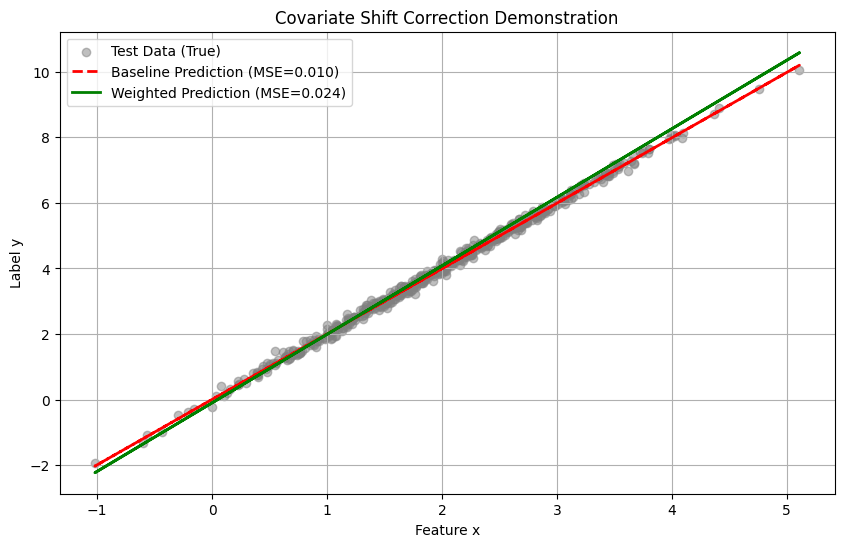

In [8]:
#5.2 编程题
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# ==========================================
# 1. 人工数据集构造
# ==========================================

np.random.seed(42)

# 训练集 P: N(-1, 1), 1000个样本
N_train = 1000
x_train = np.random.normal(loc=-1, scale=1, size=(N_train, 1))
noise = np.random.normal(0, 0.1, size=(N_train, 1)) # 小噪声 epsilon
y_train = 2 * x_train + noise

# 测试集 Q: N(2, 1), 500个样本 (发生协变量偏移)
N_test = 500
x_test = np.random.normal(loc=2, scale=1, size=(N_test, 1))
noise_test = np.random.normal(0, 0.1, size=(N_test, 1))
y_test = 2 * x_test + noise_test

print(f"训练集特征均值: {x_train.mean():.4f}")
print(f"测试集特征均值: {x_test.mean():.4f}")
print(">>> 确认存在明显的协变量偏移 (均值从 -1 变为 2)")

# ==========================================
# 3. 基线模型 (Baseline Model)
# ==========================================

# 直接在训练集 P 上训练
model_baseline = LinearRegression()
model_baseline.fit(x_train, y_train)

# 在测试集 Q 上评估
y_pred_baseline = model_baseline.predict(x_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)

print(f"\n[基线模型] 测试集 MSE: {mse_baseline:.6f}")

# ==========================================
# 4. 偏移校正实现 (Density Ratio Estimation)
# ==========================================

# (a) 训练一个逻辑回归分类器来区分源域和目标域
# 标记: 训练集为 0, 测试集为 1
X_domain = np.vstack([x_train, x_test])
y_domain = np.concatenate([np.zeros(N_train), np.ones(N_test)])

discriminator = LogisticRegression(solver='lbfgs', max_iter=1000)
discriminator.fit(X_domain, y_domain)

# 预测每个样本属于测试集 (类别1) 的概率 P(test|x)
prob_test_given_x = discriminator.predict_proba(X_domain)[:, 1]

# (b) 计算权重 w_i
# 公式推导: w(x) = p_test(x)/p_train(x) = P(test|x)/P(train|x)
# 因为 P(test|x) + P(train|x) = 1, 所以 w(x) = P(test|x) / (1 - P(test|x))

# 为了防止除以0或数值不稳定，加一个极小值 epsilon
epsilon = 1e-7
weights_full = prob_test_given_x / (1 - prob_test_given_x + epsilon)

# 提取训练集部分的权重
w_train = weights_full[:N_train]

# 归一化权重 (可选，但通常有助于数值稳定性，使总权重等于样本数)
# w_train = w_train * (N_train / w_train.sum())

print(f"[权重统计] 平均权重: {w_train.mean():.4f}, 最大权重: {w_train.max():.4f}")

# ==========================================
# 5. 加权模型训练 (Weighted Model)
# ==========================================

# 使用 sample_weight 参数进行加权最小二乘法训练
model_weighted = LinearRegression()
model_weighted.fit(x_train, y_train, sample_weight=w_train)

# 在测试集 Q 上评估
y_pred_weighted = model_weighted.predict(x_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)

print(f"\n[加权模型] 测试集 MSE: {mse_weighted:.6f}")

# ==========================================
# 结果对比与可视化
# ==========================================

print("\n================ 最终结果对比 ================")
print(f"基线模型 MSE (未校正): {mse_baseline:.6f}")
print(f"加权模型 MSE (已校正): {mse_weighted:.6f}")
print(f"性能提升幅度: {(mse_baseline - mse_weighted) / mse_baseline * 100:.2f}%")

# 绘图展示
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='gray', alpha=0.5, label='Test Data (True)')
plt.plot(x_test, y_pred_baseline, 'r--', linewidth=2, label=f'Baseline Prediction (MSE={mse_baseline:.3f})')
plt.plot(x_test, y_pred_weighted, 'g-', linewidth=2, label=f'Weighted Prediction (MSE={mse_weighted:.3f})')
plt.title('Covariate Shift Correction Demonstration')
plt.xlabel('Feature x')
plt.ylabel('Label y')
plt.legend()
plt.grid(True)
plt.show()